# Exercise 04 Task 03

# Subtask 02
Extend the Evacuation model to allow for batch runs.

In [1]:
from mesa.batchrunner import batch_run
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import sys
sys.path.insert(0,'../../../abmodel')


from fire_evacuation.model import FireEvacuation
from fire_evacuation.agent import Human

Note: room size included walls, e.g. a floor size of 12 may only accomodate 100 agents. Also note that the simulation may take a few minutes to terminate!

Some changes made to the evacuation model:

* Introduction of crows anxiety: When the proportion of agents in the neighbourhood exceeds a threshold, the panic score increases
* Panic paralysis: When panic, stop for one step with certain probability (default: 0.5)
* Panic random walk: With certain probability during panic (default: 0.3), walk in a random direction

In [5]:
from IPython.utils import io
        
params = dict(
    floor_size=10,
    human_count=40,
    alarm_believers_prop = 1.0,
    cooperation_mean = np.arange(0.1,0.7,0.1),
    nervousness_mean = np.arange(0.1,0.7,0.1),
    seed = range(1,20),
)

with io.capture_output() as captured:
    results = batch_run(
            FireEvacuation,
            parameters=params,
            iterations = 1,
            max_steps = 200,
        )

In [6]:
pd.DataFrame(results)

,RunId,iteration,Step,floor_size,human_count,alarm_believers_prop,cooperation_mean,nervousness_mean,seed,NumEscaped,AvgNervousness,AvgSpeed
0,0,-1,23,10,40,1.0,0.1,0.1,1,39,0.0,0.0
1,1,-1,13,10,40,1.0,0.1,0.1,2,40,0.0,0.0
2,2,-1,31,10,40,1.0,0.1,0.1,3,38,0.0,0.0
3,3,-1,65,10,40,1.0,0.1,0.1,4,36,0.0,0.0
4,4,-1,11,10,40,1.0,0.1,0.1,5,40,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
679,679,-1,16,10,40,1.0,0.6,0.6,15,40,0.0,0.0
680,680,-1,10,10,40,1.0,0.6,0.6,16,40,0.0,0.0
681,681,-1,14,10,40,1.0,0.6,0.6,17,40,0.0,0.0
682,682,-1,15,10,40,1.0,0.6,0.6,18,40,0.0,0.0


[Text(0, 0, '0.1'),
 Text(0, 1, '0.2'),
 Text(0, 2, '0.3'),
 Text(0, 3, '0.4'),
 Text(0, 4, '0.5'),
 Text(0, 5, '0.6')]

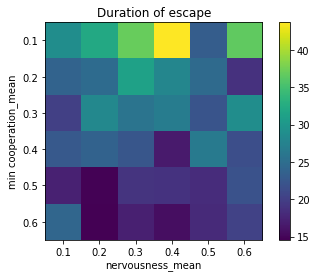

In [17]:
data = pd.DataFrame(results)[['cooperation_mean', 'nervousness_mean','Step']].round(decimals=1)
df = data.groupby(['cooperation_mean', 'nervousness_mean']).agg(np.mean)
plot_df = (df.reset_index()
              .pivot(index='cooperation_mean', columns='nervousness_mean'))

fig, ax = plt.subplots()
im = ax.imshow(plot_df)
plt.colorbar(im)
plt.xlabel('nervousness_mean')
plt.ylabel('min cooperation_mean')
plt.title("Duration of escape")
ax.set_xticks(np.arange(plot_df.shape[1]))
ax.set_xticklabels(sorted(set(round(data['nervousness_mean'], ndigits=1))))
ax.set_yticks(np.arange(plot_df.shape[0]))
ax.set_yticklabels(plot_df.index)